# Model Evaluation

## Load Models and Data

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, log_loss)

# Load feature matrix
features_df = pd.read_csv(os.path.join('..', 'Feature_Engineering', 'features.csv'))

# Load models
with open(os.path.join('..', 'Model_Training', 'xgb_model.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)

with open(os.path.join('..', 'Model_Training', 'lr_model.pkl'), 'rb') as f:
    lr_model = pickle.load(f)

with open(os.path.join('..', 'Model_Training', 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

with open(os.path.join('..', 'Model_Training', 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

print("All models loaded!")

All models loaded!


## Prepare Test Data

In [3]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'home_form', 'away_form', 'form_diff',
    'home_avg_scored', 'home_avg_conceded',
    'away_avg_scored', 'away_avg_conceded',
    'goal_diff', 'is_neutral'
]

X = features_df[feature_cols]
y = features_df['result']
weights = features_df['weight']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print("Test data ready!")

Test data ready!


## Confusion Matrix

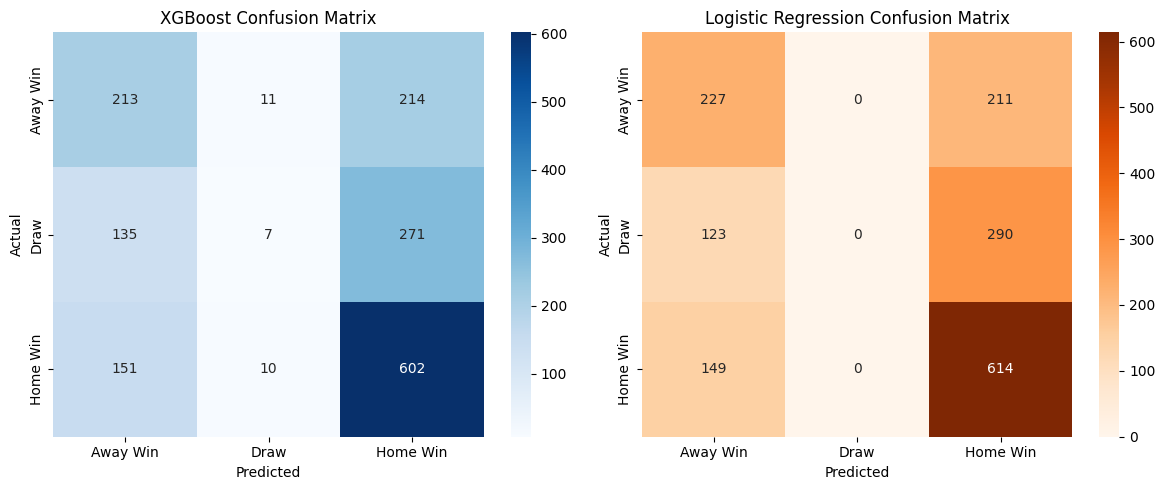

Saved!


In [5]:
# Confusion matrix shows where the model gets confused
# Rows = actual result, Columns = predicted result

xgb_preds = xgb_model.predict(X_test)
lr_preds = lr_model.predict(X_test_scaled)
lr_preds_enc = le.transform(lr_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test_enc, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'],
            cmap='Blues')
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test_enc, lr_preds_enc)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[1],
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'],
            cmap='Oranges')
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join('..', 'Evaluate', 'confusion_matrix.png'))
plt.show()
print("Saved!")

## Classification Report

In [7]:
print("XGBoost Classification Report:")
print("=" * 45)
print(classification_report(y_test_enc, xgb_preds,
      target_names=['Away Win', 'Draw', 'Home Win']))

print("\nLogistic Regression Classification Report:")
print("=" * 45)
print(classification_report(y_test_enc, lr_preds_enc,
      target_names=['Away Win', 'Draw', 'Home Win']))

XGBoost Classification Report:
              precision    recall  f1-score   support

    Away Win       0.43      0.49      0.45       438
        Draw       0.25      0.02      0.03       413
    Home Win       0.55      0.79      0.65       763

    accuracy                           0.51      1614
   macro avg       0.41      0.43      0.38      1614
weighted avg       0.44      0.51      0.44      1614


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Away Win       0.45      0.52      0.48       438
        Draw       0.00      0.00      0.00       413
    Home Win       0.55      0.80      0.65       763

    accuracy                           0.52      1614
   macro avg       0.34      0.44      0.38      1614
weighted avg       0.38      0.52      0.44      1614



C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Feature Importance (XGBoost)

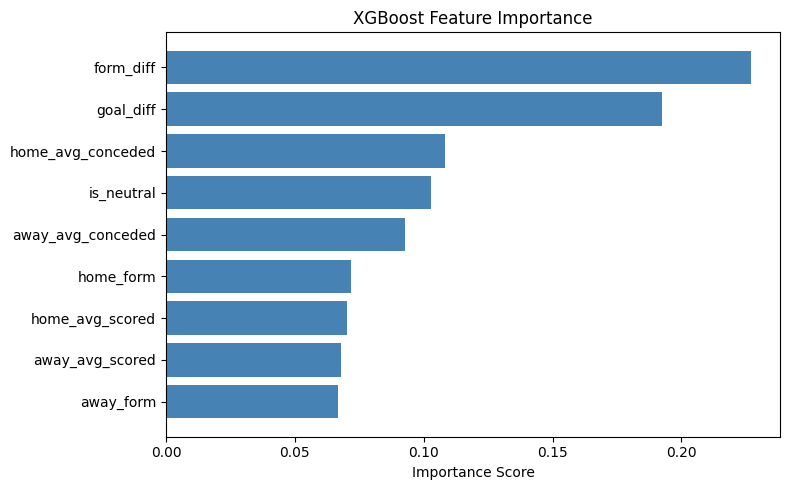

Saved!


In [8]:
# Which features matter most to the model?
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join('..', 'Evaluate', 'feature_importance.png'))
plt.show()
print("Saved!")